# Plot community compositions

Plot community compositions calculated from elementary community modes and from Pycomo for comparison.

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
with open("../run_metadata.pkl", "rb") as f:
    run_metadata = pickle.load(f)

simulated_mus = run_metadata["simulated_mus"]

In [3]:
def get_compositions(
    pattern, mus, plotted_mus, mins=None, maxs=None, organism="Geobacter"
):
    """calculate community compositions from the elementary modes.
    If there are too many modes, they are sampled,
    making sure that the extreme points are always plotted.
    """
    color = "#00a797"
    compute_extrema = mins is None or maxs is None
    max_points = 500_000
    rng = np.random.default_rng(4)
    if compute_extrema:
        mins, maxs, plotted_mus = [], [], []
    for i, mu in enumerate(mus):
        try:
            composition = pd.read_csv(
                f"../results/ecms2comp_{pattern}_{round(mu,2)}.csv", index_col=0
            )
        except FileNotFoundError:
            print(f"Results for {pattern} mu={mu} not available")
            continue
        values = composition[organism].to_numpy()
        if compute_extrema:
            plotted_mus.append(mu)
            mins.append(values.min())
            maxs.append(values.max())
        print(pattern, round(mu, 2), len(values))
        # Randomly sample points for plotting only, while always keeping the extremes
        if len(values) > max_points:
            min_idx = np.argmin(values)
            max_idx = np.argmax(values)

            mask = np.ones(len(values), dtype=bool)
            mask[min_idx] = False
            mask[max_idx] = False
            remaining_idx = np.flatnonzero(mask)

            n_sample = max_points - 2
            sampled_idx = rng.choice(remaining_idx, size=n_sample, replace=False)

            plot_idx = np.concatenate([sampled_idx, [min_idx, max_idx]])
            values_plot = values[plot_idx]
        else:
            values_plot = values
        plt.scatter(
            values_plot,
            [mu] * len(values_plot),
            color="black",
            alpha=0.6,
            zorder=2,
            s=7,
            label="EFMs" if i == 0 else None,
        )

    plotted_mus = np.array(plotted_mus)
    mins = np.array(mins)
    maxs = np.array(maxs)

    mask = mins - maxs < -1e-5

    plt.fill_betweenx(
        plotted_mus[mask],
        mins[mask],
        maxs[mask],
        alpha=0.5,
        zorder=1,
        color=color,
        label="pycomo",
    )
    plt.legend(loc="lower right")
    plt.xlabel(f"Fraction of {organism}", size=15)
    plt.ylabel("Growth rate", size=15)
    plt.title(f"Pattern {pattern}")
    plt.savefig(f"../figures/{pattern}_EFMs.png", dpi=300, bbox_inches="tight")
    plt.show()

    return plotted_mus, mins, maxs

In [4]:
pycomo_results = pd.read_csv("../results/pycomo_composition_ranges.csv")

mEmC_1 0.66 142
mEmC_1 0.6 29319
mEmC_1 0.54 15948
mEmC_1 0.47 5940
mEmC_1 0.4 7236
mEmC_1 0.33 367456
mEmC_1 0.27 12654636
mEmC_1 0.2 71584369


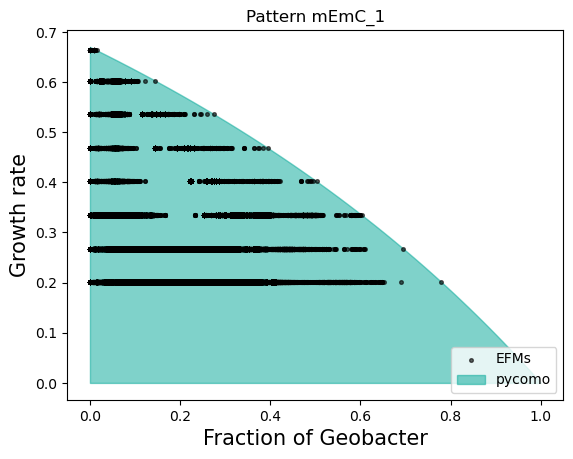

mEmC_3 0.66 40
mEmC_3 0.6 4636
mEmC_3 0.54 5586
mEmC_3 0.47 3492
mEmC_3 0.4 5580
mEmC_3 0.33 348432
mEmC_3 0.27 1171829
mEmC_3 0.2 22630723


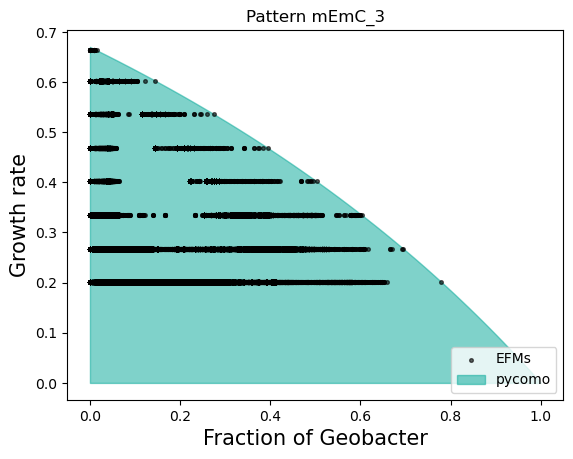

mEmC_2 0.99 22
mEmC_2 0.9 33
mEmC_2 0.8 33
mEmC_2 0.7 183
mEmC_2 0.6 1728
mEmC_2 0.5 12376
mEmC_2 0.4 24340
mEmC_2 0.3 1028577


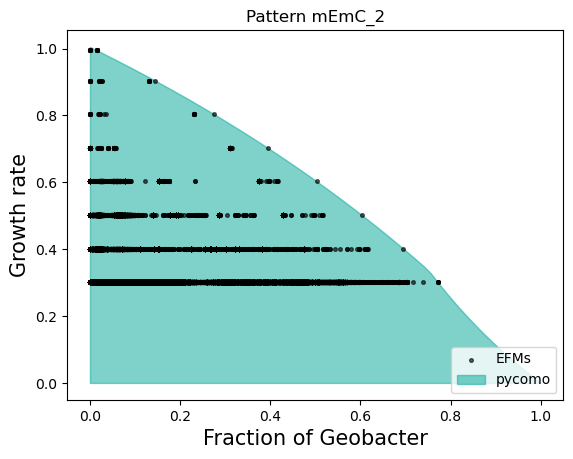

mEmC_4 0.92 3
mEmC_4 0.84 9
mEmC_4 0.74 12
mEmC_4 0.65 518
mEmC_4 0.56 4216
mEmC_4 0.47 8362
mEmC_4 0.37 34498
mEmC_4 0.28 645674


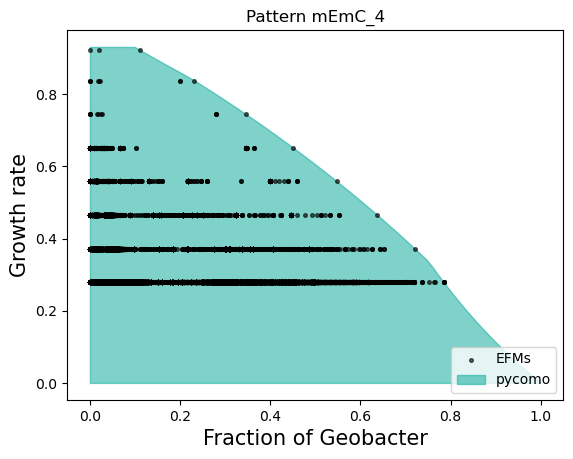

mE_1 0.37 1334
mE_1 0.33 2303
mE_1 0.3 2254
mE_1 0.26 18289
mE_1 0.22 58870
mE_1 0.18 3038257
mE_1 0.15 44599707
Results for mE_1 mu=0.11083393814592404 not available


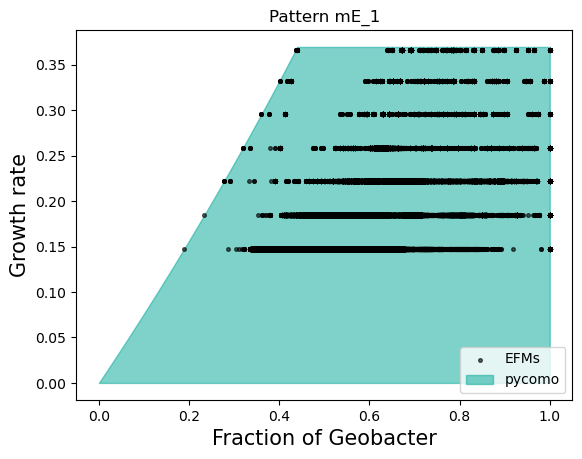

mU_1 0.37 406
mU_1 0.33 686
mU_1 0.3 1225
mU_1 0.26 14472
mU_1 0.22 37980
mU_1 0.18 149526
mU_1 0.15 5774958
mU_1 0.11 23740338


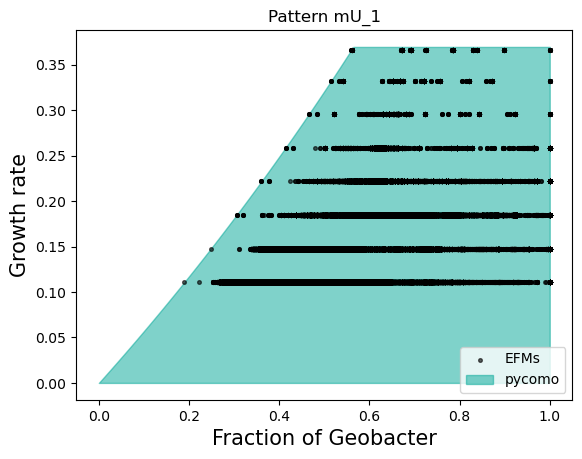

In [5]:
for pattern, mus in simulated_mus.items():
    pycomo_one = pycomo_results[pycomo_results["pattern"] == pattern]
    plotted_mus, mins, maxs = get_compositions(
        pattern, mus, pycomo_one.mu, pycomo_one.min_fraction, pycomo_one.max_fraction
    )